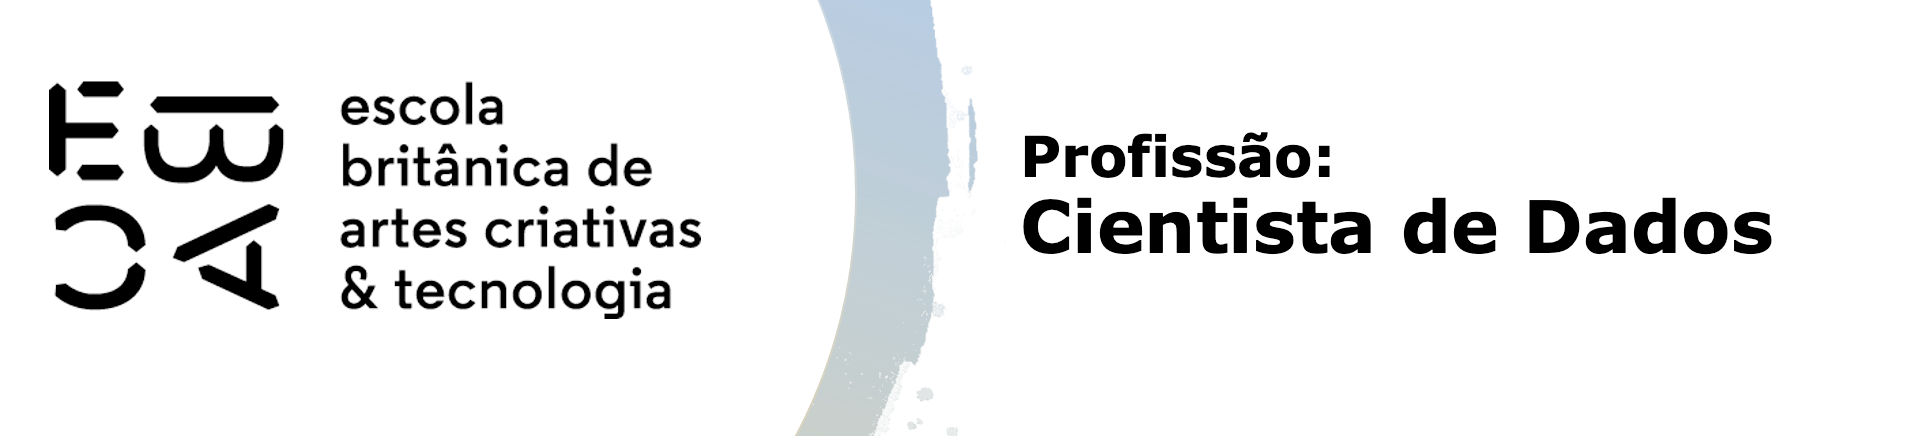

# Task II

Still on the dataset of the NFP seen in the previous task:

|Field|Description|
|:-|:-|
|CNPJ issued.| CNPJ of the NF issuer |
|Issuer| Trade name of the NF issuer |
|No.| NF number |
|Issuance Date| NF issuance date |
|NF Value| NF value |
|Registration Date| Date of registration in the NFP system |
|Credits| Value of credits (donation) |
|Credit Status| If the credit has already been paid, is being processed, etc.|
|Year| Year of NF issuance |
|Semester| Semester of NF issuance |
|Return| Credit value divided by NF value |
|flag_credit| Indicator if the NF has positive credit |
|category| NF categorization |

**OBJECTIVE**: Some NF do not provide returns, which can occur for a variety of reasons, one of which would be the occurrence of non-incentivized products such as cigarettes and alcoholic beverages. Our goal is to try to predict which type of grade is more or less likely to provide credits.

**Note**: This is a real basis, with characteristics in agreement. There may be a variability that is difficult to explain, partly because of a frequency of notes that is inconsistent over time (for various reasons), partly because there is important information, protected by the LGPD, not included in the base, which can interfere with the credit generated, the which will cause variability that is difficult to explain. Welcome to the jungle, Real life is like this :)

In [1]:
#################### IMPORTS BLOCK ####################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#################### OPENING DATA FILE ####################

df = pd.read_pickle('base_nfp.pkl')
df = df[df['Data Emissão'] >= '2020-01-01']
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 86956 entries, 64598 to 187645
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CNPJ emit.           86956 non-null  object        
 1   Emitente             86956 non-null  object        
 2   No.                  86956 non-null  int64         
 3   Data Emissão         86956 non-null  datetime64[ns]
 4   Valor NF             86956 non-null  float64       
 5   Data Registro        86956 non-null  datetime64[ns]
 6   Créditos             86956 non-null  float64       
 7   Situação do Crédito  86956 non-null  category      
 8   Ano                  86956 non-null  int64         
 9   Semestre             86956 non-null  int64         
 10  Retorno              86000 non-null  float64       
 11  flag_credito         86956 non-null  int64         
 12  categoria            86956 non-null  object        
dtypes: category(1), datetime64

## Creating variables

**Temporal variables**: It is possible that there is a rule for releasing credits according to the day of the month, day of the week, weekend (yes or no), or even temporal changes to the rule. Let's create the following variables to test these hypotheses:

- Day of the week
- Dummy for weekend
- Day of month
- Month (already in the base)
- Quarter
- Year (already in the base)

**NF value**: Let's also create some variables to summarize the score value, and later create an intuition about continuous variable categorizations.

- Create categorizations of the variable ```NF Value```, by quantiles, in 5, 10, 20 and 50 categories.

In [2]:
#################### DATA ENGINEERING - TEMPORAL VARIABLES ####################

df['Week_Days'] = df['Data Emissão'].dt.dayofweek
df['Weekend_Dummy'] = df['Week_Days'].apply(lambda x: 1 if x >= 5 else 0)
df['Day'] = df['Data Emissão'].dt.day
df['Quarter'] = df['Data Emissão'].dt.to_period('Q').astype(str)

#################### DATA ENGINEERING - SUMMARY VALUE VARIABLES ####################

labels_5 = [f'Q{i+1}' for i in range(5)]
labels_10 = [f'Q{i+1}' for i in range(10)]
labels_20 = [f'Q{i+1}' for i in range(20)]
labels_50 = [f'Q{i+1}' for i in range(50)]

df['NF - 5 cate'] = pd.qcut(df['Valor NF'], q=5, labels=labels_5)
df['NF - 10 cate'] = pd.qcut(df['Valor NF'], q=10, labels=labels_10)
df['NF - 20 cate'] = pd.qcut(df['Valor NF'], q=20, labels=labels_20)
df['NF - 50 cate'] = pd.qcut(df['Valor NF'], q=50, labels=labels_50)

df.head()

,CNPJ emit.,Emitente,No.,Data Emissão,Valor NF,Data Registro,Créditos,Situação do Crédito,Ano,Semestre,...,flag_credito,categoria,Week_Days,Weekend_Dummy,Day,Quarter,NF - 5 cate,NF - 10 cate,NF - 20 cate,NF - 50 cate
64598,05.234.750/0001-41,TX BURGER LTDA,77882,2020-01-01,78.80,2020-08-01,0.0,A Calcular,2019,2,...,0,não definido,2,0,1,2020Q1,Q3,Q6,Q12,Q28
64599,47.508.411/1476-88,CIA BRASILEIRA DE DISTRIBUICAO,20087,2020-01-01,22.71,2020-01-01,0.0,A Calcular,2019,2,...,0,Mercado,2,0,1,2020Q1,Q1,Q2,Q4,Q10
64600,09.060.964/0108-39,PIMENTA VERDE ALIMENTOS LTDA,82366,2020-01-01,35.90,2020-08-01,0.0,A Calcular,2019,2,...,0,Alimentos,2,0,1,2020Q1,Q2,Q4,Q7,Q16
64601,61.412.110/0307-39,DROGARIA SAO PAULO S A,234178,2020-01-01,21.77,2020-08-01,0.0,A Calcular,2019,2,...,0,Farmácia,2,0,1,2020Q1,Q1,Q2,Q4,Q9
64602,46.952.032/0001-98,PANIFICADORA E CONFEITARIA QUELUZ LTDA,3305,2020-01-01,80.95,2020-08-01,0.0,A Calcular,2019,2,...,0,Restaurantes,2,0,1,2020Q1,Q3,Q6,Q12,Q29


## Calculate the IV of all these variables

**Suggestion**: Build metadata and try to use a function like the one used during class. You will be able to do this calculation for the variables one by one, but in real cases where we go further in creating variables, we can have hundreds, or even thousands of variables, these calculations *need* to be automatic in these cases.

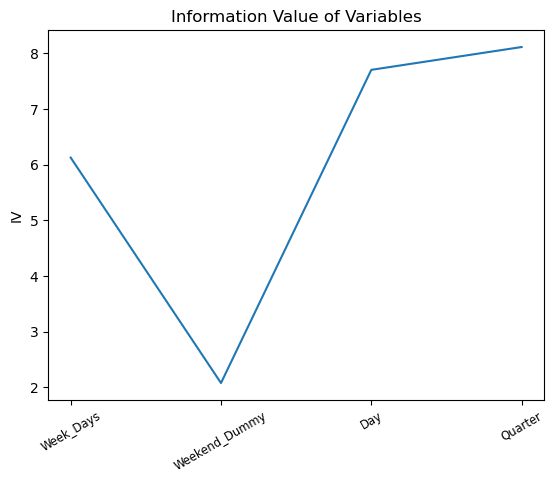

,nunique,IV
Week_Days,7,6.128115
Weekend_Dummy,2,2.078959
Day,31,7.704437
Quarter,8,8.11424


In [3]:
#################### FUNCTIONS BLOCK ####################

def IV(var, target):
    crosstab = pd.crosstab(var, target, margins=True, margins_name='Total')
    
    label_yes = crosstab.columns[0]
    label_no = crosstab.columns[1]
    
    crosstab['pct_yes'] = crosstab[label_yes] / crosstab.loc['Total', label_yes]
    crosstab['pct_no'] = crosstab[label_no] / crosstab.loc['Total', label_no]
    
    # Tratar zeros para evitar divisão por zero
    crosstab['pct_yes'].replace(0, 0.0001, inplace=True)
    crosstab['pct_no'].replace(0, 0.0001, inplace=True)
    
    crosstab['woe'] = np.log(crosstab['pct_yes'] / crosstab['pct_no'])
    crosstab['parcial_IV'] = (crosstab['pct_yes'] - crosstab['pct_no']) * crosstab['woe']
    
    return crosstab['parcial_IV'].sum()

def plot_iv(IV):
    fig, ax = plt.subplots()

    ax.plot(IV)
    
    ax.set_title("Information Value of Variables")
    ax.set_ylabel('IV')
    ax.set_xlabel('')
    plt.xticks(rotation=30, fontsize='small')
    plt.show()

def calculate_woe_iv(df, variable, target, period):
    woe_iv = []
    
    for p in df[period].unique():
        subset = df[df[period] == p]
        crosstab = pd.crosstab(subset[variable], subset[target], margins=True, margins_name='Total')
        
        label_yes = crosstab.columns[0]
        label_no = crosstab.columns[1]
        
        crosstab['pct_yes'] = crosstab[label_yes] / crosstab.loc['Total', label_yes]
        crosstab['pct_no'] = crosstab[label_no] / crosstab.loc['Total', label_no]
        
        crosstab['pct_yes'].replace(0, 0.0001, inplace=True)
        crosstab['pct_no'].replace(0, 0.0001, inplace=True)
        
        crosstab['woe'] = np.log(crosstab['pct_yes'] / crosstab['pct_no'])
        crosstab['iv'] = (crosstab['pct_yes'] - crosstab['pct_no']) * crosstab['woe']
        
        woe_iv.append({
            period: p,
            'WOE': crosstab['woe'].values,
            'IV': crosstab['iv'].sum()
        })
    
    woe_iv_df = pd.DataFrame(woe_iv)
    
    return woe_iv_df

metadata = pd.DataFrame(columns=['nunique', 'IV'])

for col in ['Week_Days', 'Weekend_Dummy', 'Day', 'Quarter']:
    metadata.loc[col, 'nunique'] = df[col].nunique()
    if metadata.loc[col, 'nunique'] > 5 and df[col].dtype != 'object':
        try:
            metadata.loc[col, 'IV'] = IV(pd.qcut(df[col].astype(float), 5, duplicates='drop'), df['Retorno'])
        except ValueError:
            metadata.loc[col, 'IV'] = IV(df[col], df['Retorno'])
    else:
        metadata.loc[col, 'IV'] = IV(df[col], df['Retorno'])

plot_iv(metadata['IV'])

metadata

## Conclude

- Which variables seem to have the greatest power of discrimination according to the IV?

> "Day" and "Quarter" have the greatest discrimination power

- When we categorize continuous variables, does there seem to be any relationship between the number of categories and the IV?

> Seems that higher the amount of categories, higher the IV... until certain point, obviously. Like all others optmization problems, there is a trade-off of somekind.

## Basic Descriptive over Time

To compose the analysis that will follow, carry out a basic descriptive analysis over time - use quarter as an aggregation (or a moving average per quarter, as you prefer) and evaluate graphically:

- The number of notes registered in the database per period
- The number of notes per category and period
- The proportion of grades with credit per category per period

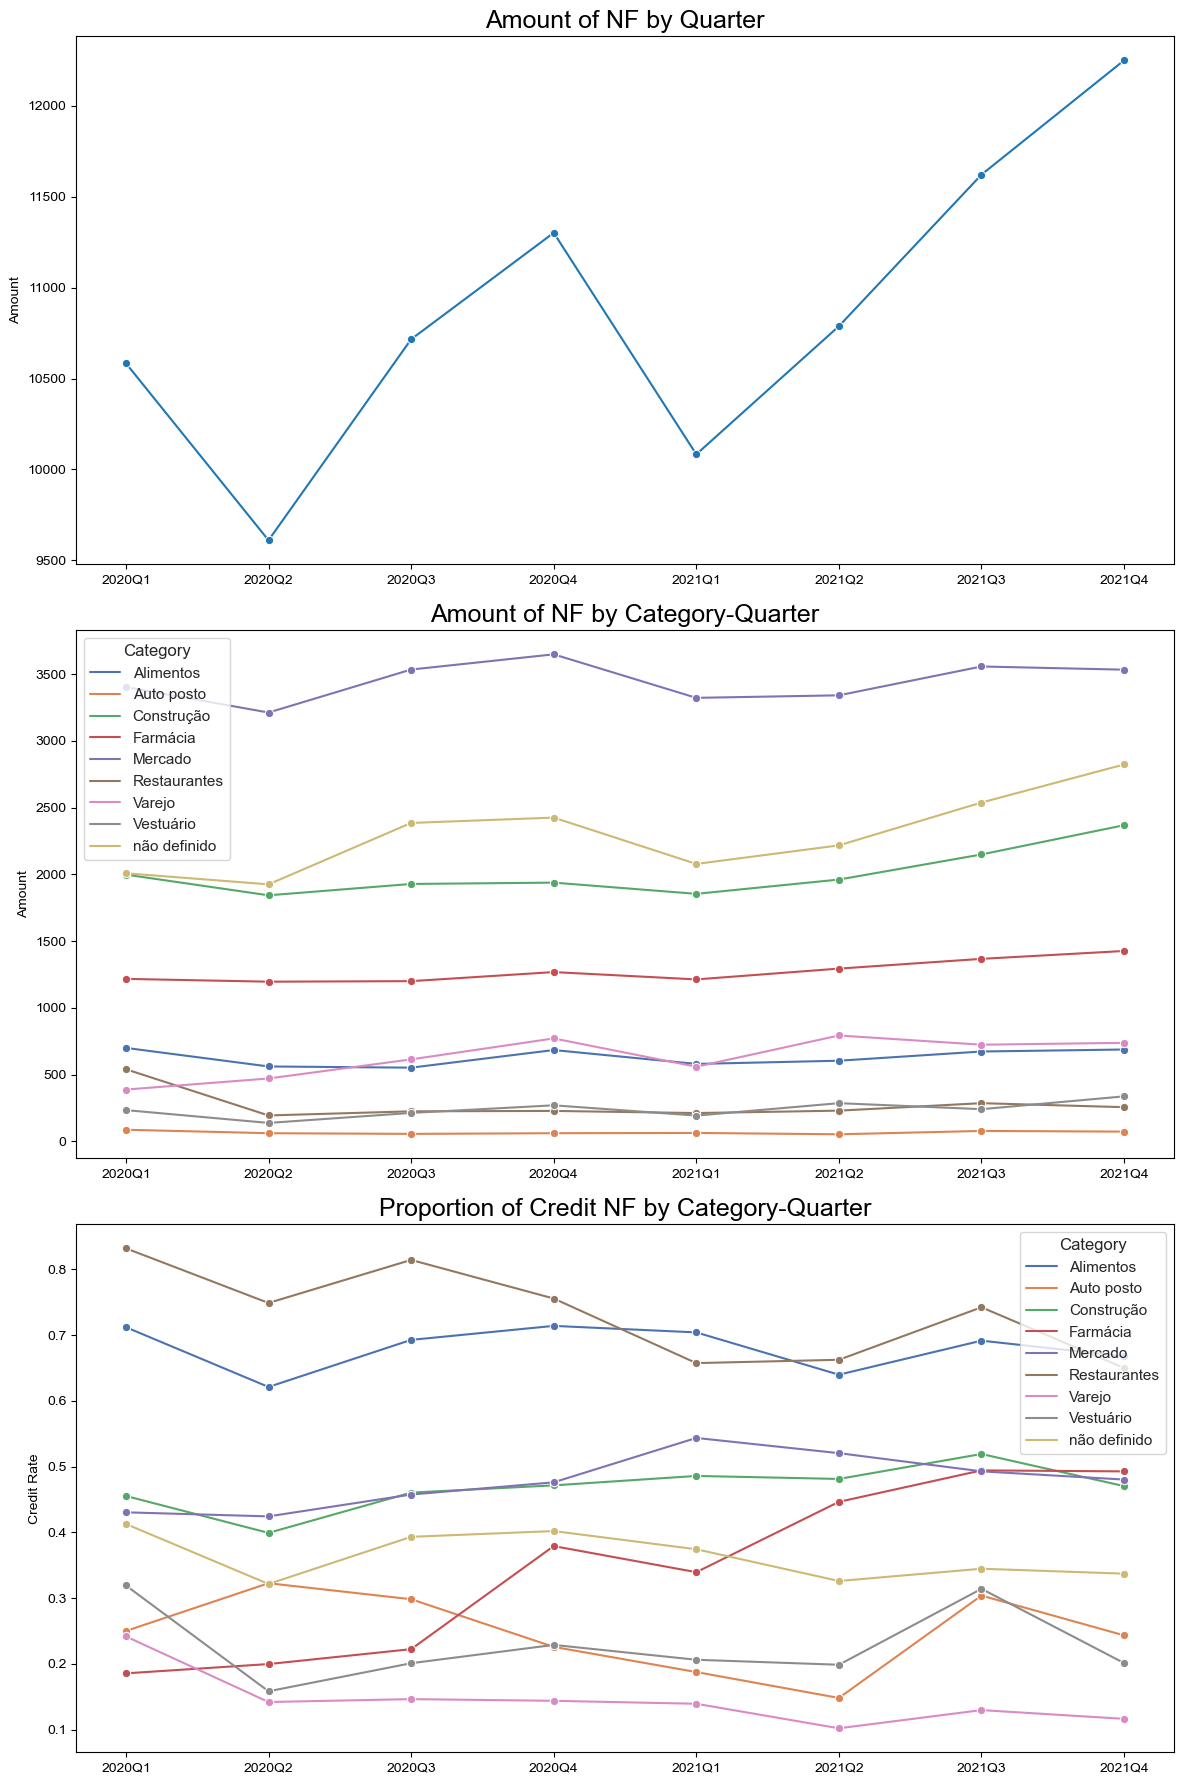

In [4]:
#################### DATA ENGINEERING - TIME AND CATEGORY RELATION ####################

byquarter = df.groupby('Quarter').size().reset_index(name='NF amount')
byquarter_cate = df.groupby(['Quarter', 'categoria']).size().reset_index(name='NF amount')
credit_byquarter_cate = df[df['flag_credito'] == 1].groupby(['Quarter',
                                                             'categoria']).size().reset_index(name='Credit NF amount')

total_byquarter_cate = df.groupby(['Quarter', 'categoria']).size().reset_index(name='Total NF')

credit_byquarter_cate = pd.merge(credit_byquarter_cate, total_byquarter_cate, on=['Quarter', 'categoria'])
credit_byquarter_cate['Credit Rate'] = credit_byquarter_cate['Credit NF amount'] / credit_byquarter_cate['Total NF']

#################### PLOTTING THE NEW DATA ####################

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

sns.lineplot(data=byquarter, x='Quarter', y='NF amount', ax=axes[0], marker='o')
axes[0].set_title('Amount of NF by Quarter', fontsize=18)
axes[0].set_xlabel('')
axes[0].set_ylabel('Amount')

sns.lineplot(data=byquarter_cate, x='Quarter', y='NF amount', hue='categoria', ax=axes[1], marker='o')
axes[1].set_title('Amount of NF by Category-Quarter', fontsize=18)
axes[1].set_xlabel('')
axes[1].set_ylabel('Amount')
axes[1].legend(title='Category')

sns.lineplot(data=credit_byquarter_cate, x='Quarter', y='Credit Rate', hue='categoria', ax=axes[2], marker='o')
axes[2].set_title('Proportion of Credit NF by Category-Quarter', fontsize=18)
axes[2].set_xlabel('')
axes[2].set_ylabel('Credit Rate')
axes[2].legend(title='Category')

plt.tight_layout()
plt.show()

## Evaluate WOE and IV over time

Evaluate the WOE and IV in time of the ```category``` variable.

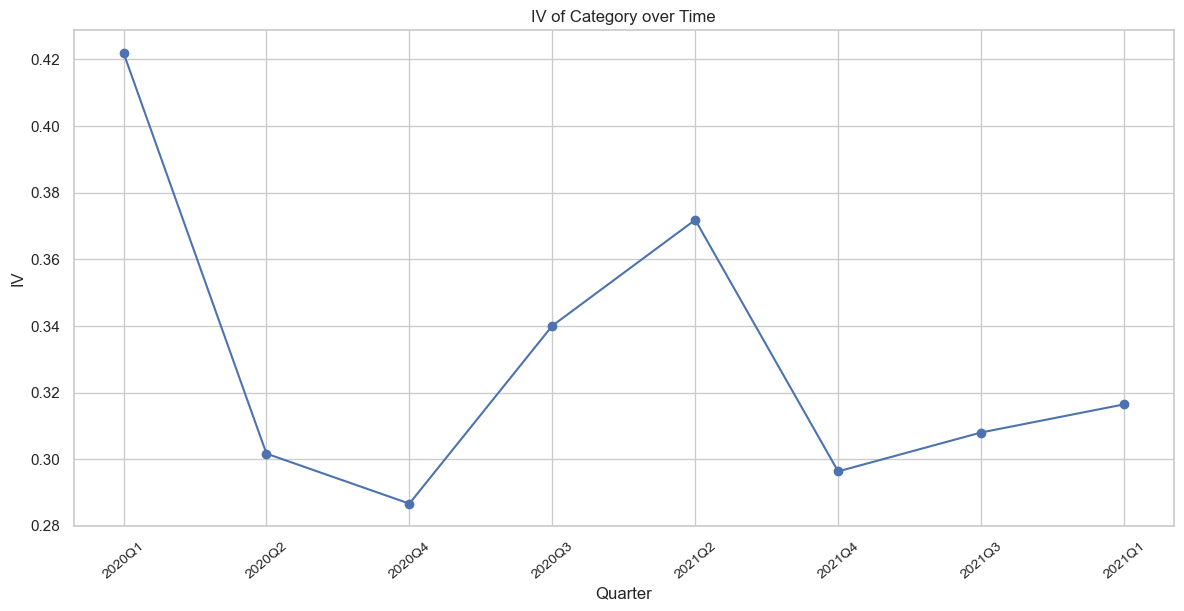

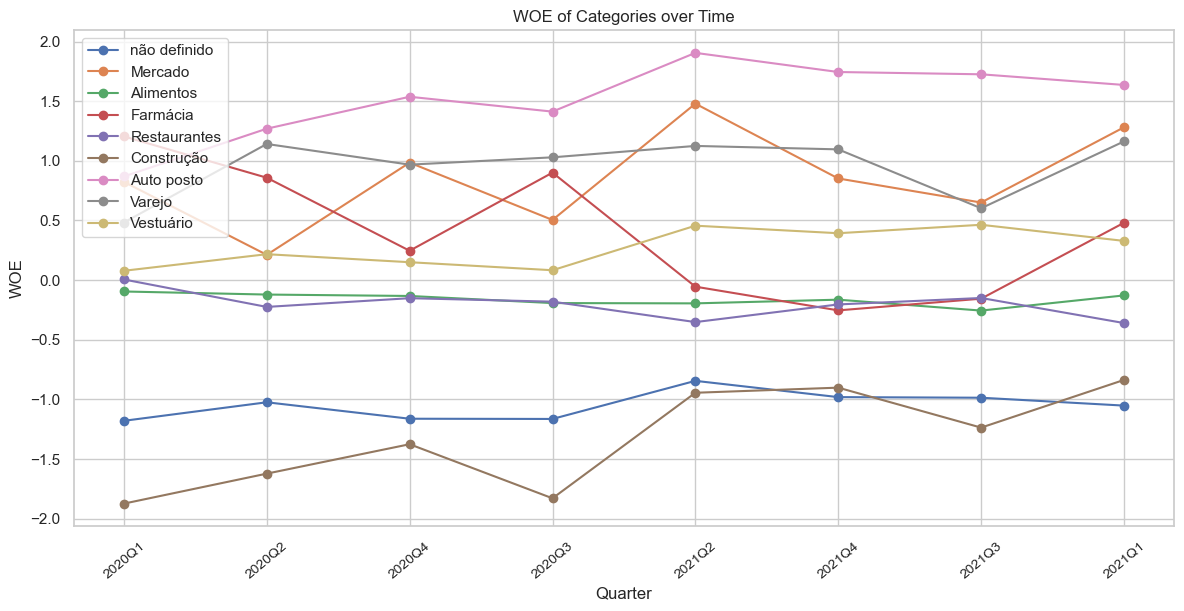

In [6]:
#################### OBJECTIVES OVER TIME ####################

woe_iv_categoria = calculate_woe_iv(df, 'categoria', 'flag_credito', 'Quarter')

fig1, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Quarter')
ax1.set_ylabel('IV')
ax1.plot(woe_iv_categoria['Quarter'], woe_iv_categoria['IV'], marker='o')
ax1.tick_params(axis='y')
ax1.set_title('IV of Category over Time')

fig1.tight_layout()
plt.xticks(rotation=40, fontsize='small')
plt.show()

fig2, ax2 = plt.subplots(figsize=(12, 6))

ax2.set_xlabel('Quarter')
ax2.set_ylabel('WOE')

for i, cat in enumerate(df['categoria'].unique()):
    ax2.plot(woe_iv_categoria['Quarter'], [woe[i] for woe in woe_iv_categoria['WOE']], label=f'{cat}', marker='o')
ax2.tick_params(axis='y')
ax2.set_title('WOE of Categories over Time')

fig2.tight_layout()
plt.legend(loc='upper left')
plt.xticks(rotation=40, fontsize='small')
plt.show()

## Conclusion

- Which categories appear to have the highest proportion of NF with returns greater than zero?

> "Restaurants" & "Foods" have the consistent higher pay-off proportions.

- Are these differences stable over time?

> Considering that we have very small dataset of time to work with, I can guess that it's stable enough over time. Despite its ponctual variations, any of the categories does not leap over or fall down.

Tips:<br>
- Consider that the number of notes is increasing
- Consider that there are very atypical periods in history
- Consider that as of January 2020 the audience is more similar to the current audience (2022 **[?]**), whether due to the pandemic or audience growth, and consider the data from that date onwards in your conclusion.